In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_pickle("../data/processed/movies_features.pkl")

cluster_features = ["runtime", "budget", "revenue", "popularity", "vote_average", "n_genres", "n_keywords"]

cluster_df = df[cluster_features].copy()
cluster_df = cluster_df.fillna(cluster_df.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

X_scaled.shape

(1719, 7)

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score
    print(f"k={k}: silhouette={score:.3f}")

k=2: silhouette=0.274
k=3: silhouette=0.172
k=4: silhouette=0.182
k=5: silhouette=0.192
k=6: silhouette=0.181
k=7: silhouette=0.166
k=8: silhouette=0.161
k=9: silhouette=0.156
k=10: silhouette=0.156


In [3]:
best_k = 5
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_scaled)

df["cluster"].value_counts().sort_index()

cluster
0    600
1    607
2    263
3     14
4    235
Name: count, dtype: int64

In [4]:
cluster_summary = df.groupby("cluster")[cluster_features].mean().round(2)
cluster_summary["count"] = df["cluster"].value_counts().sort_index()
cluster_summary

,runtime,budget,revenue,popularity,vote_average,n_genres,n_keywords,count
cluster,,,,,,,,
0,105.24,5.370859e+07,1.391979e+08,20.45,6.39,2.42,11.28,600
1,124.24,3.614815e+07,1.579354e+08,20.65,7.50,2.48,21.14,607
2,99.40,9.051391e+07,3.083077e+08,22.36,6.99,4.32,14.89,263
3,114.29,1.106750e+08,7.910660e+08,299.64,7.66,2.64,11.64,14
4,135.42,1.865889e+08,7.556217e+08,30.45,7.13,2.98,17.78,235


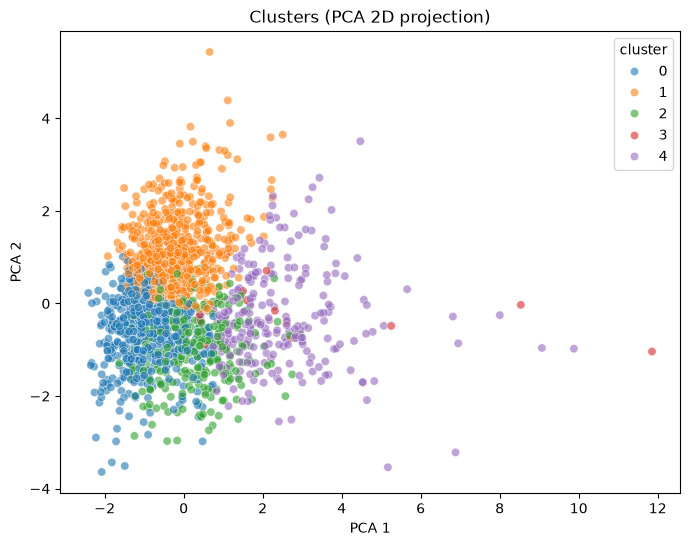

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=df["cluster"], palette="tab10", alpha=0.6)
plt.title("Clusters (PCA 2D projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [7]:
print("Variance explained by PC1, PC2:", pca.explained_variance_ratio_)

Variance explained by PC1, PC2: [0.28643147 0.2040788 ]


In [8]:
import joblib

joblib.dump(kmeans_final, "../models/kmeans_model.pkl")
joblib.dump(scaler, "../models/cluster_scaler.pkl")
df.to_pickle("../data/processed/movies_clustered.pkl")

print("saved")

saved
